## 0 · 环境 + 加载数据 + 前处理（与第 1 本相同，快速带过）

In [ ]:
import importlib
for m in ['numpy','pandas','matplotlib','sklearn','torch']:
    print('OK ', m, importlib.import_module(m).__version__ if m!='sklearn' else importlib.import_module('sklearn').__version__)

OK  numpy 2.5.0
OK  pandas 3.0.3
OK  matplotlib 3.11.0
OK  sklearn 1.9.0
OK  torch 2.12.1+cpu


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 自动找 data 文件夹
CANDS = [
    '../../workshop_build/workshop_build/09_advanced_ml/gan/data',
    'workshop_build/workshop_build/09_advanced_ml/gan/data',
    'data', '../data', '../../gan/data',
]
DATA = None
for guess in CANDS:
    if os.path.exists(os.path.join(guess, 'stakeholder_relations.parquet')):
        DATA = guess; break
print('文件夹：', DATA)

df = pd.read_parquet(os.path.join(DATA, 'stakeholder_relations.parquet'))
print('数据形状：', df.shape, '(列 = 街区, 栏 = 特征)')
df.head()

資料夾： ../../workshop_build/workshop_build/09_advanced_ml/gan/data
資料形狀： (5438, 16) (列 = 街區, 欄 = 特徵)


,site,gx,gy,n_bld,share_state,share_developer,share_resident,share_unknown,dominant_share,mix_entropy,n_stakeholders,hhi,co_state_developer,co_state_resident,co_developer_resident,log_area_share
0,beiwaitan,888,8644,31,0.430228,0.390706,0.092771,0.086296,0.430228,8.382444e-01,4,0.353800,0.409991,0.199781,0.190384,1.063913
1,beiwaitan,888,8645,157,0.096402,0.733344,0.142557,0.027697,0.733344,5.987057e-01,3,0.568176,0.265886,0.117230,0.323332,1.823628
2,beiwaitan,889,8645,182,0.187530,0.502309,0.294390,0.015772,0.502309,7.827995e-01,3,0.374396,0.306917,0.234961,0.384545,1.845814
3,beiwaitan,889,8644,40,0.337147,0.622987,0.000000,0.039866,0.622987,5.697437e-01,2,0.503370,0.458299,0.000000,0.000000,0.935038
4,beiwaitan,887,8644,16,0.000000,1.000000,0.000000,0.000000,1.000000,5.979471e-11,1,1.000000,0.000000,0.000000,0.000000,0.645861


In [3]:
# 让 matplotlib 显示中文（找不到字体就略过，不影响程序）
from matplotlib import font_manager as fm
for fp in [
    '../../.venv/Lib/site-packages/matplotlib/mpl-data/fonts/ttf/NotoSansCJKsc-Regular.otf',
    '../../../.venv/Lib/site-packages/matplotlib/mpl-data/fonts/ttf/NotoSansCJKsc-Regular.otf',
    'C:/Windows/Fonts/msjh.ttc',
]:
    if os.path.exists(fp):
        try:
            fm.fontManager.addfont(fp)
            plt.rcParams['font.sans-serif'] = [fm.FontProperties(fname=fp).get_name()]
            break
        except Exception: pass
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 选特征栏 + 标准化（ML 三本都要的前处理）
drop = ['site', 'gx', 'gy']
feat_cols = [c for c in df.columns
             if c not in drop and np.issubdtype(df[c].dtype, np.number)]
X = df[feat_cols].to_numpy(dtype='float32')
mu = X.mean(axis=0); sd = X.std(axis=0); sd[sd < 1e-8] = 1.0
Xs = (X - mu) / sd

share_cols = ['share_state','share_developer','share_resident','share_unknown']
share_idx  = [feat_cols.index(c) for c in share_cols]
names  = ['state 政府','developer 开发商','resident 居民','unknown 未知']
colors = ['#1f77b4','#d62728','#2ca02c','#7f7f7f']
dominant = X[:, share_idx].argmax(axis=1)
print('特征栏 %d 个，标准化后 Xs =' % len(feat_cols), Xs.shape)

特徵欄 13 個，標準化後 Xs = (5438, 13)


## 1 · `class`：自订一个「类型」

到目前用的都是现成东西（list、DataFrame）。神经网络要**自己定义一个类型**，用 `class`。
先用一个生活化例子看懂 `class` / `__init__` / `self` / 方法。

In [5]:
class Dog:
    def __init__(self, name):     # 建构式：造一只狗时跑一次
        self.name = name          # self = 这只狗自己，把名字存起来
    def bark(self):               # 方法 = 绑在对象上的函数
        return self.name + ' 汪汪!'

d = Dog('小黑')
print(d.name)
print(d.bark())

小黑
小黑 汪汪!


**对照神经网络**：`__init__` 里盖零件、`forward` 里定义数据怎么流过去。下面是 `2_AE.ipynb` 的模型，逐行对照。

## 2 · `nn.Module`：神经网络的 class

```python
class AE(nn.Module):          # 继承 nn.Module（取得训练所需的全部机制）
    def __init__(self):
        super().__init__()    # 先让父类别初始化（固定要写）
        self.enc = nn.Sequential(...)  # encoder 13→2 压缩
        self.dec = nn.Sequential(...)  # decoder 2→13 还原
    def forward(self, x):     # 数据流过网络
        z = self.enc(x)
        return self.dec(z), z
```
- `nn.Linear(a, b)`：一层全连接，把 a 个数字转成 b 个。
- `nn.ReLU()`：把负数变 0 的「激活函数」，让网络能学弯曲。
- `nn.Sequential(...)`：把好几层串起来，依序通过。

In [6]:
import torch
import torch.nn as nn
torch.manual_seed(0)
D = Xs.shape[1]

class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(D, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 2),
        )
        self.dec = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, D),
        )
    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

model = AE()
print(model)

AE(
  (enc): Sequential(
    (0): Linear(in_features=13, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
  (dec): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=13, bias=True)
  )
)


## 3 · 训练循环：看懂「训练」那一格

训练 = **一个 for 循环，重复很多回合，每回合让误差小一点**。固定五步：
```python
for epoch in range(80):
    xh, z = model(xt)         # 1 喂数据
    loss  = loss_fn(xh, xt)   # 2 算误差（还原 vs 原始）
    opt.zero_grad()           # 3 清掉上回梯度
    loss.backward()           # 4 算这回要怎么调
    opt.step()                # 5 真的调参数
```

In [ ]:
from tqdm.auto import tqdm

xt = torch.tensor(Xs)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

history = []
pbar = tqdm(range(1000), desc='训练')
for epoch in pbar:
    xh, z = model(xt)
    loss = loss_fn(xh, xt)
    opt.zero_grad(); loss.backward(); opt.step()
    history.append(loss.item())
    pbar.set_postfix(误差=f'{loss.item():.4f}')
print('训练完成！')

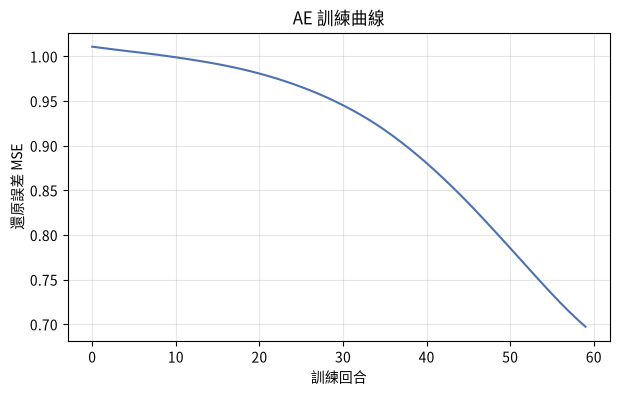

In [8]:
# 训练曲线：往下掉 = 越学越好
plt.figure(figsize=(7,4))
plt.plot(history, color='#4C72B0')
plt.xlabel('训练回合'); plt.ylabel('还原误差 MSE')
plt.title('AE 训练曲线'); plt.grid(alpha=0.3); plt.show()

## 4 · 用训练好的模型看结果

`model.eval()` + `with torch.no_grad()`：只看结果、不算梯度（比较快）。

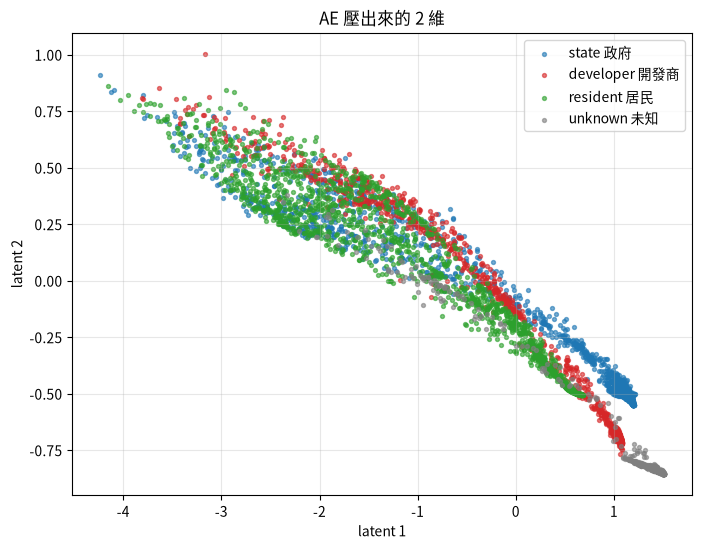

In [9]:
model.eval()
with torch.no_grad():
    _, Z = model(xt)
Z = Z.numpy()

plt.figure(figsize=(8,6))
for i in range(4):
    m = (dominant == i)
    plt.scatter(Z[m,0], Z[m,1], s=8, c=colors[i], label=names[i], alpha=0.6)
plt.xlabel('latent 1'); plt.ylabel('latent 2')
plt.title('AE 压出来的 2 维'); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5 · 练习：改参数重跑

回到 §3 把 `range(60)` 改成 `range(150)`，或把 `lr=1e-3` 改成 `1e-2`，再跑一次，
看训练曲线和点图怎么变。**这就是你在三本 notebook 里会做的事。**

---
## 第 2 本完成
你会了：`class` / `nn.Module`（`__init__`、`forward`、`self`）/ `nn.Linear`+`ReLU`+`Sequential` / 训练五步 / `eval()`+`no_grad()`。

**下一步**：打开 **`PCA_AE_VAE_教学.ipynb`**，搞懂 PCA / AE / VAE 三种压法**差在哪**（图像化）。
之后就能完整读懂 `1_PCA` / `2_AE` / `3_VAE` 三本。